# **Collaborative Anime Filtering**

This section implements a **`Collaborative Filtering`** approach to recommend anime to users based on historical rating patterns. It typically uses techniques like matrix factorization (e.g., `SVD`) or neighborhood-based algorithms (e.g., `KNNBasic`) provided by the **`Surprise`** library. The goal is to predict user preferences by leveraging similarities between users or items.

* Reinstall Specific Version of **`NumPy`** (v1.26.4)

In [ ]:
!pip install numpy==1.26.4 --force-reinstall --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 308.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


* Install **`Surprise`** Library for Recommender Systems


In [ ]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2469542 sha256=4114580d77c8540cc96ff496fe51e7985d64fac58266fb5b78b954b50d8a384d
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


## **Library Imports and Environment Setup**

In [ ]:
# Imports
import pandas as pd
import numpy as np
import warnings
import pickle
import os
import matplotlib.pyplot as plt
from surprise import (
    Reader, Dataset, SVD, SVDpp, KNNBasic, KNNWithZScore,
    BaselineOnly, NMF, accuracy
)
from surprise.model_selection import cross_validate, GridSearchCV
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Disable warnings
warnings.filterwarnings('ignore')

## **Data Exploration and preprocessing**

* Loading the user-anime rating dataset from a CSV file and removes duplicate entries. The file contains historical rating scores, which will be used to train the collaborative filtering model.

In [ ]:
ratings_df = pd.read_csv('/content/drive/MyDrive/Anime Recommender System/users-score-2023.csv')
ratings_df = ratings_df.drop_duplicates(subset=['user_id', 'anime_id'])

* **Prepare Data for Surprise Library**:

  * 📝 **Summary**:

    * Preparing the cleaned ratings data for modeling with the `Surprise` library:

    * A `Reader` object is created to define the rating scale dynamically based on the actual `min` and `max` values in the dataset.

    * The `ratings_df` is transformed into a Dataset format that `Surprise` can work with by selecting only the necessary columns: `user_id`, `anime_id`, and `rating`.

This setup enables algorithms like `SVD`, `KNN`, and `NMF` to train on structured `user-item` interaction data.


In [ ]:
reader = Reader(rating_scale=(ratings_df['rating'].min(), ratings_df['rating'].max()))
train_data = Dataset.load_from_df(ratings_df[['user_id', 'anime_id', 'rating']], reader)

* **Build Full Training Set for Model**

* 📝 Summary:
  * Converting the `Surprise` Dataset object into a Trainset object using .`build_full_trainset()`. The `trainset` is a matrix-style internal representation used by all `Surprise` algorithms for training.

  * this includes all available ratings without `splitting`, meaning the model will train on 100% of the data.

In [ ]:
trainset = train_data.build_full_trainset()

* **Train `SVD` Model with Cross-Validation**

  * 📝 Summary (Markdown Cell):
    * initializing and evaluates an SVD (Singular Value Decomposition) model using 5-fold cross-validation on the dataset.

    * `SVD()` is a matrix factorization algorithm that learns latent features for users and items.

    * `cross_validate()` splits the data into `5 folds` and computes evaluation metrics:

      * `RMSE (Root Mean Squared Error)`

      * `MAE (Mean Absolute Error)`

Results (stored in `cv_results`) include **average performance** and **training/testing time per fold**.

This is a standard way to assess how well the model generalizes before deploying.

In [ ]:
model = SVD()
cv_results = cross_validate(model, train_data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.2537  1.2527  1.2534  1.2538  1.2548  1.2537  0.0007  
MAE (testset)     0.9261  0.9257  0.9256  0.9262  0.9264  0.9260  0.0003  
Fit time          286.62  290.84  323.92  288.92  290.76  296.21  13.94   
Test time         110.29  88.17   83.31   87.45   76.39   89.12   11.38   


* **Conclusion**:
  * The cross-validation results indicate that the `SVD` model performs consistently across all 5 folds with minimal variation in error metrics:

  * The `RMSE` scores are tightly clustered around `1.2537`, and the `MAE` values center near `0.9260`, suggesting stable predictive performance across folds.

  * The fit times vary slightly more (especially in Fold 3), but remain within a reasonable range for training on the full dataset.

  * **The test times decrease gradually**, which may reflect caching effects or system load differences but do not significantly impact evaluation consistency.

  These results demonstrate that `SVD` is a reliable choice for `Collaborative Filtering` in this anime recommendation context, balancing accuracy and computational cost effectively.

### **Train NMF Model with Cross-Validation**

  * Initializing and evaluates the `NMF (Non-negative Matrix Factorization)` model using `5-fold` cross-validation.

  * `NMF()` is a latent factor model similar to `SVD` but enforces non-negativity on the factorized matrices, which can make results more interpretable in some contexts (e.g., ratings can’t be negative).

  * `cross_validate()` computes `RMSE` and `MAE scores` for each fold to assess accuracy and generalizability.

In [ ]:
model3 = NMF()
cv_results3 = cross_validate(model3, train_data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm NMF on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    2.1817  2.1768  2.1722  2.1773  2.1686  2.1753  0.0045  
MAE (testset)     1.9119  1.9062  1.9016  1.9070  1.8979  1.9049  0.0048  
Fit time          444.63  451.36  452.43  451.94  453.82  450.84  3.21    
Test time         70.93   64.93   71.47   64.80   71.32   68.69   3.13    


Conclusion:
  * The `NMF (Non-negative Matrix Factorization)` model yielded consistent but **relatively higher error rates compared to `SVD`**:

  * The average `RMSE` across folds was `2.1753`, with **a low standard deviation** of `±0.0045`, **indicating stable error margins but noticeably higher prediction error than `SVD (1.2537)`**.

  * The **`MAE` was similarly stable (1.9049 ± 0.0048)** but **again higher than the `SVD counterpart (0.9260)`**, **suggesting that the model struggles to predict precise ratings**.

  * Training times were considerably **longer** `(~450 seconds on average)`, **which reflects the heavier computational cost of the `NMF` algorithm**.

  * Test times remained reasonable and consistent `(mean: 68.69 seconds)`, indicating predictable evaluation performance.

### **Train Item-Based KNN Model with Cross-Validation**

building and evaluating an `item-based Collaborative Filtering` model using the`KNNBasic` algorithm from the surprise library.

  * `Similarity metric`: `Cosine similarity` is used to compute the closeness between items.

  * `user_based=False` specifies that recommendations should be made based on `item-item` similarity instead of `user-user`.

  * The model is evaluated using `5-fold cross-validation` and tracks both `RMSE` and `MAE` to assess performance.

In [ ]:
sim_options = {
    'name': 'cosine',  # Cosine similarity (can also use 'pearson')
    'user_based': False  # False → Item-based
}
model2 = KNNBasic(sim_options=sim_options)
cv_results2 = cross_validate(model2, train_data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.3807  1.3808  1.3807  1.3790  1.3793  1.3801  0.0008  
MAE (testset)     1.0370  1.0372  1.0374  1.0354  1.0364  1.0367  0.0007  
Fit time          266.49  282.66  291.02  287.58  299.50  285.45  10.96   
Test time         819.10  827.54  816.43  917.87  896.85  855.56  42.97   


Conclusion:
  * The `item-based` `KNNBasic` model using `Cosine Similarity` showed moderate predictive performance and high computational cost during testing:

  * The average `RMSE` across the `5 folds` was `1.3801 ± 0.0008`, which is better than `NMF (2.1753)` but worse than SVD (1.2537).

  * The `MAE` was `1.0367 ± 0.0007`, again landing between `SVD (0.9260)` and `NMF (1.9049)`.

  * Training times were reasonable at around `285` seconds, similar to `SVD` and `faster than NMF`.

  * However, test times were very high, averaging `~855` seconds per fold, with `significant variability (±42.97 s)`, likely due to the cost of computing the similarity matrix and predictions for all item pairs.

  * While the model is stable and interpretable, the high inference cost and only moderate accuracy make `KNNBasic` less `favorable` than `SVD` in this context.

## **Model Evaluation Comparison: `RMSE` & `MAE` of `SVD`, `NMF`, and `KNNBasic`**

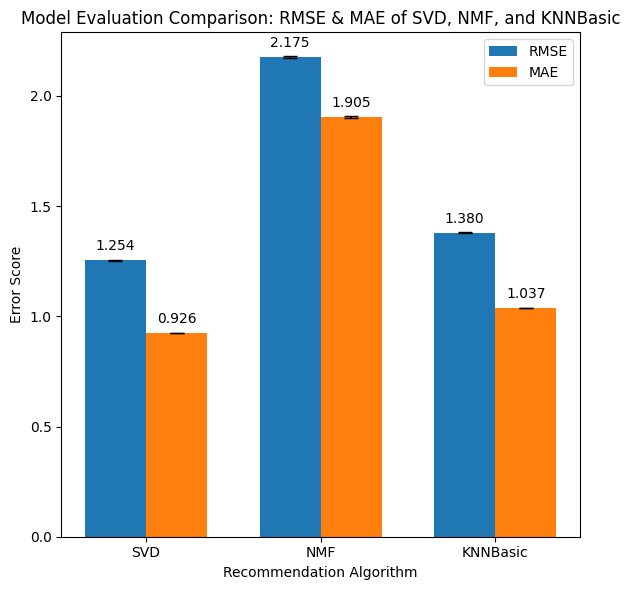

In [ ]:
# Model names
models = ['SVD', 'NMF', 'KNNBasic']

# Mean and Std for RMSE and MAE
rmse_means = [1.2537, 2.1753, 1.3801]
rmse_stds = [0.0007, 0.0045, 0.0008]
mae_means = [0.9260, 1.9049, 1.0367]
mae_stds = [0.0003, 0.0048, 0.0007]

# X-axis positions
x = np.arange(len(models))
width = 0.35  # width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot RMSE and MAE bars with error bars
rmse_bars = ax.bar(x - width/2, rmse_means, width, yerr=rmse_stds, label='RMSE', capsize=5)
mae_bars = ax.bar(x + width/2, mae_means, width, yerr=mae_stds, label='MAE', capsize=5)

# Set labels and title
ax.set_ylabel('Error Score')
ax.set_xlabel('Recommendation Algorithm')
ax.set_title('Model Evaluation Comparison: RMSE & MAE of SVD, NMF, and KNNBasic')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Annotate bars with values
for bars in [rmse_bars, mae_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom')

# Final layout without grid
plt.tight_layout()
plt.show()


As we see:
* `SVD` has the lowest `RMSE` and `MAE`, meaning it performed best.

* `NMF` has the highest errors, making it the least accurate.

* `KNNBasic` performs better than `NMF` but worse than `SVD`.



## **Save the best model**

In [ ]:
# Define full save path
save_path = '/content/drive/MyDrive/Anime Recommender System/svd_best_model13.pkle'

# Save the trained SVD model
with open(save_path, 'wb') as f:
    pickle.dump(model, f)

### **Define Hyperparameter Grid for SVD(Best Model) Tuning**

Defining a hyperparameter grid for `fine-tuning` the `SVD` model using `grid search`. **Each combination of parameters will be tested during cross-validation to find the optimal configuration.**

The parameters include:

  * `n_factors`: Number of latent factors (controls model complexity).

  * `n_epochs`: Number of training iterations.

  * `lr_all`: Learning rate for all model parameters.

  * `reg_all`: Regularization term to prevent overfitting.

These values will be passed to `GridSearchCV` to identify the `best model` configuration based on performance metrics (`RMSE` or `MAE`).

In [ ]:
# Define the parameter grid
param_grid = {
    'n_factors': [50, 100, 150],
    'n_epochs': [10, 20, 30],
    'lr_all': [0.001, 0.005, 0.01],
    'reg_all': [0.01, 0.02, 0.05]
}

* This step performs an exhaustive `Grid Search` using `GridSearchCV` to find the **optimal** hyperparameters for the `SVD` model based on `RMSE` and `MAE` performance using `5-fold cross-validation`.

* The grid defined earlier is passed to `GridSearchCV` with `SVD` as the algorithm.

* The search evaluates all parameter combinations across `5 folds`.

* After training, the best parameters for minimizing `RMSE` are retrieved and printed.

* This step ensures the `SVD` model is finely tuned for optimal prediction accuracy on this dataset.

In [ ]:
# Set up GridSearchCV with 5-fold cross-validation
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=5)

# Fit the grid search on the training data
gs.fit(train_data)

In [ ]:
# Retrieve the best parameters for minimizing RMSE
best_params = gs.best_params['rmse']
print("Best parameters for RMSE:", best_params)
print("Best RMSE score:", gs.best_score['rmse'])

In [ ]:
best_params = gs.best_params['rmse']
final_model = SVD(**best_params)
final_model.fit(train_data.build_full_trainset())